# Perceptrón Multicapa (2 Capa Oculta) — Clasificación binaria de género en Twitter

**Taller 1 — Deep Learning (2026-10)**

**Modelo:** Red Neuronal Feed-Forward (MLP) con una capa oculta.

**Objetivo:** Clasificar usuarios de Twitter como `male (0)` o `female (1)`.

Los datos ya fueron preprocesados en `Taller1DL.ipynb` (secciones 1-5) y se cargan desde archivos `.npy`.

---

## 1. Carga de datos preprocesados

Los archivos `.npy` contienen las matrices ya:
- Imputadas (nulos tratados)
- Escaladas (StandardScaler para numéricas)
- Codificadas (OneHotEncoder para categóricas)
- Particionadas (60% train, 20% val, 20% test)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar matrices preprocesadas generadas en Taller1DL.ipynb
preprocessed_dir = "preprocessed_data"
X_train = np.load(f"{preprocessed_dir}/X_train.npy")
X_val   = np.load(f"{preprocessed_dir}/X_val.npy")
X_test  = np.load(f"{preprocessed_dir}/X_test.npy")
y_train = np.load(f"{preprocessed_dir}/y_train.npy")
y_val   = np.load(f"{preprocessed_dir}/y_val.npy")
y_test  = np.load(f"{preprocessed_dir}/y_test.npy")

print("="*50)
print("  DIMENSIONES DE LOS DATOS")
print("="*50)
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val:   X={X_val.shape},   y={y_val.shape}")
print(f"  Test:  X={X_test.shape},  y={y_test.shape}")
print(f"\n  Número de features: {X_train.shape[1]}")
print(f"  Clases únicas: {np.unique(y_train)}  (0=male, 1=female)")

numero_entradas = X_train.shape[1]

  DIMENSIONES DE LOS DATOS
  Train: X=(7736, 9), y=(7736,)
  Val:   X=(2579, 9),   y=(2579,)
  Test:  X=(2579, 9),  y=(2579,)

  Número de features: 9
  Clases únicas: [0 1]  (0=male, 1=female)


## 2. ¿Qué es el Perceptrón Multicapa (MLP) con 2 Capas Ocultas?

El **Perceptrón Multicapa (MLP)** es una red neuronal artificial feed-forward. Supera las limitaciones del perceptrón unicapa, permitiendo aprender patrones y fronteras de decisión **no lineales** mediante múltiples capas de procesamiento.

### Arquitectura:
```
Capa de Entrada   Capa Oculta 1    Capa Oculta 2    Capa de Salida

x₁ ───┐           ┌─── h₁⁽¹⁾ ───┐   ┌─── h₁⁽²⁾ ───┐
x₂ ───┼─ W⁽¹⁾ ────┼─── h₂⁽¹⁾ ───┼─ W⁽²⁾ ─┼─── h₂⁽²⁾ ───┼─ W⁽³⁾ ─→ ŷ ∈ {0,1}
 ⋮    │           │     ⋮        │         │     ⋮        │
xₙ ───┘           └─── hₖ⁽¹⁾ ───┘         └─── hₖ⁽²⁾ ───┘
```

Para este punto el taller establece que **la primera capa oculta debe tener la mitad de neuronas que las entradas** ($k = n/2$), **la segunda capa oculta debe tener el mismo número de neuronas que la primera** ($k = n/2$), y **la tercera capa es la de salida** con una neurona para clasificación binaria.

### Componentes:
- **Capa de Entrada:** Recibe las $n$ features preprocesadas (entradas $x_i$).
- **Primera Capa Oculta:** Contiene $k = n/2$ neuronas. Aplica una transformación lineal a las entradas, seguida de una función de activación no lineal (**ReLU**).
- **Segunda Capa Oculta:** Contiene $k = n/2$ neuronas (igual que la primera). Aplica otra transformación no lineal (**ReLU**) permitiendo aprender representaciones jerárquicas más complejas.
- **Capa de Salida:** Contiene 1 sola neurona (por ser clasificación binaria). Procesa la salida de la segunda capa oculta y aplica función de activación (**Sigmoide**).
- **Pesos y Sesgos:** Matrices de pesos $W^{(1)}, W^{(2)}, W^{(3)}$ y sesgos $b^{(1)}, b^{(2)}, b^{(3)}$ que se ajustan durante el entrenamiento.

### Funciones de Activación:

**1. Capas Ocultas 1 y 2 (ReLU - Rectified Linear Unit):**

Primera capa oculta:
$$h_j^{(1)} = \max(0, \sum_{i=1}^{n} W^{(1)}_{ji} x_i + b^{(1)}_j)$$

Segunda capa oculta:
$$h_j^{(2)} = \max(0, \sum_{i=1}^{k} W^{(2)}_{ji} h_i^{(1)} + b^{(2)}_j)$$

ReLU introduce la no-linealidad en el modelo, permitiendo aprender representaciones complejas y jerárquicas. Es computacionalmente eficiente y mitiga el problema del desvanecimiento del gradiente. Al tener dos capas ocultas, el modelo puede capturar patrones de mayor complejidad y abstracciones de nivel superior.

**2. Capa de Salida (Sigmoide):**
$$\hat{y} = \sigma(\sum_{j=1}^{k} W^{(3)}_{j} h_j^{(2)} + b^{(3)}) = \frac{1}{1 + e^{-z}}$$

Mapea el resultado a un valor continuo entre $0$ y $1$. En problemas bi-clase (female vs male), el umbral por defecto es $0.5$: si $\hat{y} \geq 0.5$ se clasifica como female (1), de lo contrario como male (0).

### Regla de Aprendizaje (Backpropagation):
El MLP utiliza el algoritmo de **retropropagación (backpropagation)** en conjunto con el optimizador **Adam** para minimizar la función de pérdida **Binary Crossentropy**. Los errores se propagan desde la capa de salida hacia las capas ocultas 2 y 1, actualizando los pesos en cada capa:
$$W^{(l)} \leftarrow W^{(l)} - \eta \frac{\partial L}{\partial W^{(l)}}$$

donde $l \in \{1, 2, 3\}$ representa cada capa. Adam adapta la tasa de aprendizaje $\eta$ durante el entrenamiento, mejorando la convergencia.

### Ventajas de 2 Capas Ocultas:
- **Mayor capacidad representacional:** Puede aprender funciones y patrones más complejos que una red con una sola capa oculta.
- **Aprendizaje jerárquico:** La primera capa aprende características de bajo nivel, mientras la segunda capa combina estas características para formar representaciones de mayor abstracción.
- **Mejor capacidad de generalización:** Para problemas complejos, las capas adicionales pueden mejorar el rendimiento en datos no vistos.

## 3. Construcción y Entrenamiento del Modelo MLP
A diferencia del Perceptrón de Scikit-Learn, aquí utilizaremos **Keras (TensorFlow)** para construir la red neuronal multicapa.

### Hiperparámetros:
| Parámetro | Valor | Descripción |
|---|---|---|
| Optimizador | Adam | Método de descenso de gradiente estocástico eficiente |
| Función de Pérdida | Binary Crossentropy | Ideal para clasificación binaria |
| Épocas | 100 | Ciclos completos de entrenamiento |
| Batch Size | 32 | Número de muestras procesadas antes de actualizar los pesos |

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Definición de la arquitectura del modelo
model_mlp_2 = Sequential()

# Capa de entrada explícita
model_mlp_2.add(Input(shape=(X_train.shape[1],)))

# Primera capa oculta (mitad de neuronas que features + ReLU)
model_mlp_2.add(Dense(
    X_train.shape[1] // 2,
    activation="relu"
))

# Segunda capa oculta (misma cantidad de neuronas + ReLU)
model_mlp_2.add(Dense(
    X_train.shape[1] // 2,
    activation="relu"
))

# Capa de salida (1 neurona + sigmoid para binaria)
model_mlp_2.add(Dense(1, activation="sigmoid"))

# Compilación con Adam y binary_crossentropy
model_mlp_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("="*50)
print("  ARQUITECTURA DEL MODELO")
print("="*50)
model_mlp_2.summary()

  ARQUITECTURA DEL MODELO


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Entrenamiento
print("\nIniciando entrenamiento...")
history = model_mlp_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Iniciando entrenamiento...
Epoch 1/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5106 - loss: 0.7001 - val_accuracy: 0.5219 - val_loss: 0.6941
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5228 - loss: 0.6939 - val_accuracy: 0.5281 - val_loss: 0.6911
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5242 - loss: 0.6918 - val_accuracy: 0.5421 - val_loss: 0.6897
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5323 - loss: 0.6908 - val_accuracy: 0.5471 - val_loss: 0.6889
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5352 - loss: 0.6900 - val_accuracy: 0.5467 - val_loss: 0.6880
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5375 - loss: 0.6893 - val_accuracy: 0.5502 - val_loss: 0.6875
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5326 - loss: 0.6890 - val_accuracy: 0.5459 - val_loss: 0.6870
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.53

### Evolución del Entrenamiento (Pérdida y Precisión)

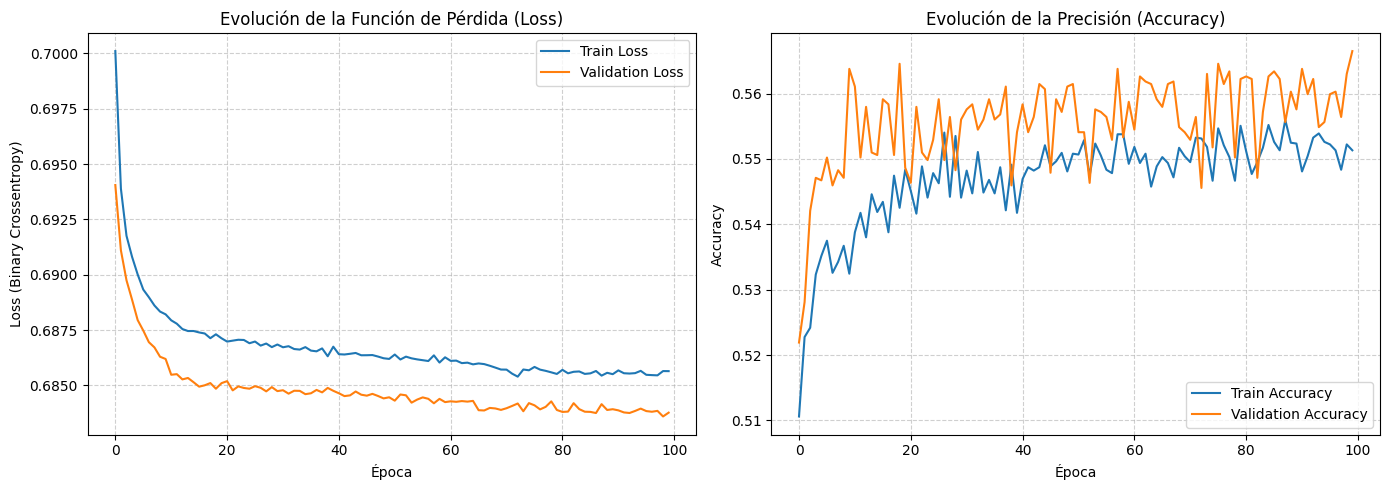

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Validation Loss')
ax[0].set_title('Evolución de la Función de Pérdida (Loss)')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Loss (Binary Crossentropy)')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

# Gráfica de Accuracy
ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Evolución de la Precisión (Accuracy)')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Predicciones

In [6]:
# Predicciones (Probabilidades)
y_train_prob = model_mlp_2.predict(X_train)
y_val_prob   = model_mlp_2.predict(X_val)
y_test_prob  = model_mlp_2.predict(X_test)

# Conversión a clases (umbral 0.5)
y_train_pred = (y_train_prob > 0.5).astype(int).flatten()
y_val_pred   = (y_val_prob > 0.5).astype(int).flatten()
y_test_pred  = (y_test_prob > 0.5).astype(int).flatten()

# Verificación rápida
print("="*50)
print("  MUESTRA DE PREDICCIONES (Test, primeras 20)")
print("="*50)
print(f"  Real:      {y_test[:20]}")
print(f"  Predicho:  {y_test_pred[:20]}")
coincidencias = np.sum(y_test[:20] == y_test_pred[:20])
print(f"  Aciertos:  {coincidencias}/20")

242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 584us/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step
  MUESTRA DE PREDICCIONES (Test, primeras 20)
  Real:      [0 0 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 0]
  Predicho:  [0 0 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 0]
  Aciertos:  14/20


## 5. Evaluación y Métricas

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluar(y_true, y_pred, nombre):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy:  {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=["male (0)", "female (1)"]))

    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

m_train = evaluar(y_train, y_train_pred, "TRAIN")
m_val   = evaluar(y_val, y_val_pred, "VALIDACIÓN")
m_test  = evaluar(y_test, y_test_pred, "TEST")

resumen = pd.DataFrame({
    "Train": m_train,
    "Validación": m_val,
    "Test": m_test
}).T

print("\nMLP 1 Capa Oculta — Resumen de métricas")
print("="*55)
display(resumen.round(4))


  TRAIN
  Accuracy:  0.5499  (54.99%)
  Precision: 0.5598
  Recall:    0.6264
  F1 Score:  0.5912

              precision    recall  f1-score   support

    male (0)       0.54      0.47      0.50      3716
  female (1)       0.56      0.63      0.59      4020

    accuracy                           0.55      7736
   macro avg       0.55      0.55      0.55      7736
weighted avg       0.55      0.55      0.55      7736


  VALIDACIÓN
  Accuracy:  0.5665  (56.65%)
  Precision: 0.5743
  Recall:    0.6403
  F1 Score:  0.6055

              precision    recall  f1-score   support

    male (0)       0.56      0.49      0.52      1239
  female (1)       0.57      0.64      0.61      1340

    accuracy                           0.57      2579
   macro avg       0.57      0.56      0.56      2579
weighted avg       0.57      0.57      0.56      2579


  TEST
  Accuracy:  0.5630  (56.30%)
  Precision: 0.5728
  Recall:    0.6254
  F1 Score:  0.5979

              precision    recall  f1-scor

,Accuracy,Precision,Recall,F1
Train,0.5499,0.5598,0.6264,0.5912
Validación,0.5665,0.5743,0.6403,0.6055
Test,0.5630,0.5728,0.6254,0.5979


## 6. Matriz de Confusión (Conjunto de Prueba)

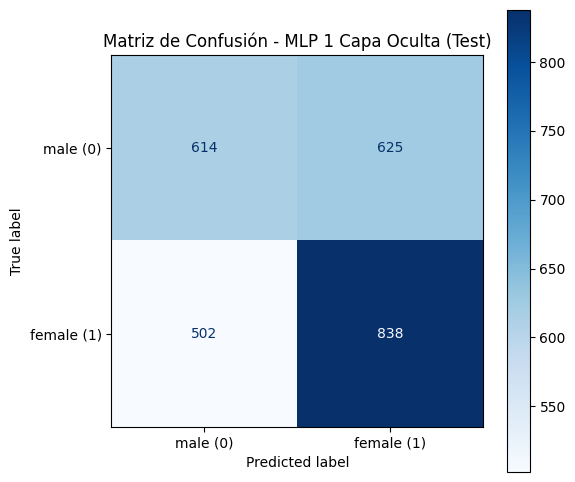

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["male (0)", "female (1)"]
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - MLP 1 Capa Oculta (Test)')
plt.grid(False)
plt.show()